# **EfficientNetB5 w/o XAI**

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4090


In [2]:
import os
import numpy as np
import tensorflow as tf
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB5
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns

2025-09-03 12:06:41.090164: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-03 12:06:41.099771: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756879601.111780  456196 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756879601.115482  456196 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1756879601.125810  456196 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
# BPHE preprocessing function
def bphe_rgb(img):
    if img.max() <= 1.0:
        img = (img * 255).astype(np.uint8)
    else:
        img = img.astype(np.uint8)

    ycrcb = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)
    y, cr, cb = cv2.split(ycrcb)
    y_eq = cv2.equalizeHist(y)
    ycrcb_eq = cv2.merge((y_eq, cr, cb))
    img_eq = cv2.cvtColor(ycrcb_eq, cv2.COLOR_YCrCb2RGB)

    return preprocess_input(img_eq.astype(np.float32))

In [4]:
# Filtered dataset directories
filtered_train_dir = '/mnt/d/FA019/new/SplittedDataset/train'
filtered_val_dir = '/mnt/d/FA019/new/SplittedDataset/val'
filtered_test_dir = '/mnt/d/FA019/new/SplittedDataset/test'

In [5]:
# Parameters
img_size = (224, 224)
batch_size = 32  # Updated
dropout_rate = 0.3  # Updated
num_classes = len(os.listdir(filtered_train_dir))

In [6]:
# Data generators
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest')

train_generator = train_datagen.flow_from_directory(
    filtered_train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical')

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_generator = val_datagen.flow_from_directory(
    filtered_val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical')

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_generator = test_datagen.flow_from_directory(
    filtered_test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False)

Found 1614 images belonging to 5 classes.
Found 229 images belonging to 5 classes.
Found 466 images belonging to 5 classes.


In [7]:
# Load base model
base_model = EfficientNetB5(weights='imagenet', include_top=False, input_shape=(img_size[0], img_size[1], 3))
base_model.summary()

I0000 00:00:1756879615.647371  456196 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20812 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "efficientnetb5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      1,152 │ block1a_se_excit

 Total params: 28,513,527 (108.77 MB)

 Trainable params: 28,340,784 (108.11 MB)

 Non-trainable params: 172,743 (674.78 KB)

In [8]:
# Custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='swish')(x)
x = Dropout(dropout_rate)(x)
x = Dense(512, activation='swish')(x)
x = Dropout(dropout_rate)(x)
x = Dense(1024, activation='swish')(x)
x = Dropout(dropout_rate)(x)
x = Dense(512, activation='swish')(x)
x = Dropout(dropout_rate)(x)
predictions = Dense(num_classes, activation='softmax')(x)

# Final model
model = Model(inputs=base_model.input, outputs=predictions)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      1,152 │ block1a_se_excit

 Total params: 32,189,180 (122.79 MB)

 Trainable params: 32,016,437 (122.13 MB)

 Non-trainable params: 172,743 (674.78 KB)

In [9]:
!pip install pydot graphviz
from tensorflow.keras.utils import plot_model

# Save the model diagram as an image file
plot_model(model, to_file='custom_efficientnetb5_model.png', show_shapes=True, show_layer_names=True)




[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [10]:

# unfreeze last 50 layers
for layer in base_model.layers[-50:]:
    layer.trainable = True

model.compile(optimizer=RMSprop(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
history= model.fit(train_generator, epochs=30, validation_data=val_generator)




/mnt/d/FA011/tf_gpu_env/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1756879720.952185  456782 service.cc:152] XLA service 0x7e5cac032a00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1756879720.952216  456782 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2025-09-03 12:08:41.910873: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1756879727.823357  456782 cuda_dnn.cc:529] Loaded cuDNN version 90701
2025-09-03 12:08:52.681875: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_43559', 204 bytes spill stores, 204 bytes spill loads

2025-09-03 12:08:52.818298: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_43

30/51 ━━━━━━━━━━━━━━━━━━━━ 16s 773ms/step - accuracy: 0.2631 - loss: 1.6010

2025-09-03 12:13:56.833722: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_43559', 12 bytes spill stores, 12 bytes spill loads

2025-09-03 12:13:57.097673: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_43559', 112 bytes spill stores, 112 bytes spill loads

2025-09-03 12:13:57.102611: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_43559', 8 bytes spill stores, 8 bytes spill loads

2025-09-03 12:13:57.103222: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_43559', 8 bytes spill stores, 8 bytes spill loads

2025-09-03 12:13:57.258422: I external

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.2792 - loss: 1.5943

2025-09-03 12:20:10.033410: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4832', 8 bytes spill stores, 8 bytes spill loads

2025-09-03 12:20:10.039740: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4832', 12 bytes spill stores, 12 bytes spill loads

2025-09-03 12:20:12.207343: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4832', 112 bytes spill stores, 112 bytes spill loads

2025-09-03 12:20:12.225676: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4832', 8 bytes spill stores, 8 bytes spill loads

2025-09-03 12:20:12.471599: I external/loc

51/51 ━━━━━━━━━━━━━━━━━━━━ 970s 13s/step - accuracy: 0.2798 - loss: 1.5940 - val_accuracy: 0.2445 - val_loss: 1.5605
Epoch 2/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 167s 3s/step - accuracy: 0.4927 - loss: 1.3572 - val_accuracy: 0.2969 - val_loss: 1.6053
Epoch 3/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 183s 3s/step - accuracy: 0.6022 - loss: 0.9666 - val_accuracy: 0.5240 - val_loss: 1.1643
Epoch 4/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 148s 3s/step - accuracy: 0.6339 - loss: 0.8405 - val_accuracy: 0.6419 - val_loss: 0.8518
Epoch 5/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 127s 3s/step - accuracy: 0.7125 - loss: 0.7223 - val_accuracy: 0.4978 - val_loss: 1.2068
Epoch 6/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.7305 - loss: 0.6933 - val_accuracy: 0.7074 - val_loss: 0.6971
Epoch 7/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.7532 - loss: 0.5872 - val_accuracy: 0.6856 - val_loss: 0.7373
Epoch 8/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.7586 - loss: 0.5645 - val_accuracy: 0.6201 - val_loss: 1

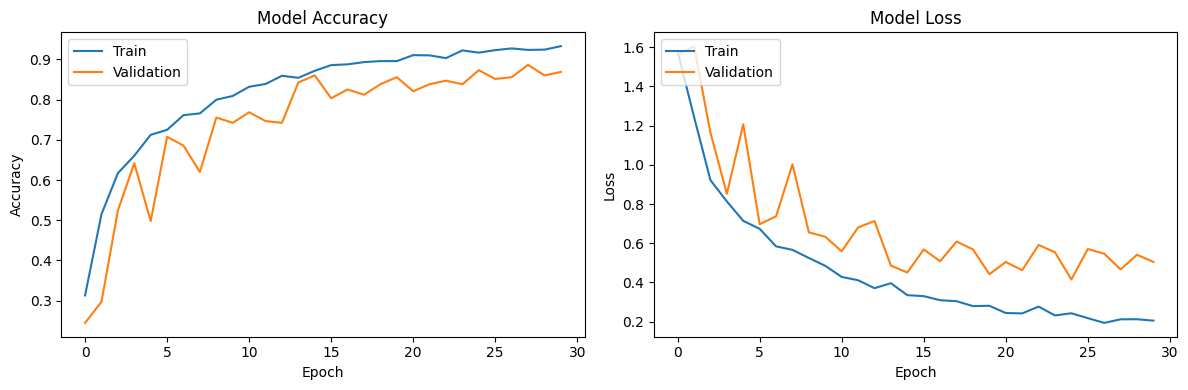

In [11]:
# Plot accuracy and loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [12]:
# Evaluate the model
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc) #80=84.5, 90 = 84.54 ,100p=84.97%, 100=86.69, 100(extra layers)=79% , 110=86.26, 120=86.4, 120p = 85.1, 150 = 84.33, 200p = 86.26, 300=86.48
print("Test Loss:", test_loss)

14/15 ━━━━━━━━━━━━━━━━━━━━ 2s 3s/step - accuracy: 0.8686 - loss: 0.4645

2025-09-03 13:26:23.085604: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4832', 4 bytes spill stores, 4 bytes spill loads

2025-09-03 13:26:23.113274: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4832', 8 bytes spill stores, 8 bytes spill loads

2025-09-03 13:26:23.118187: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4832', 220 bytes spill stores, 220 bytes spill loads

2025-09-03 13:26:23.254406: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4832', 4384 bytes spill stores, 4228 bytes spill loads

2025-09-03 13:26:23.288658: I external

15/15 ━━━━━━━━━━━━━━━━━━━━ 218s 16s/step - accuracy: 0.8695 - loss: 0.4646
Test Accuracy: 0.8755365014076233
Test Loss: 0.46494483947753906


In [13]:
# Predictions
test_generator.reset()
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

15/15 ━━━━━━━━━━━━━━━━━━━━ 90s 4s/step


In [14]:
# Metrics
conf_matrix = confusion_matrix(true_classes, predicted_classes)
class_report = classification_report(true_classes, predicted_classes, target_names=['0', '1', '2', '3', '4'])
precision = precision_score(true_classes, predicted_classes, average='weighted')
recall = recall_score(true_classes, predicted_classes, average='weighted')
f1 = f1_score(true_classes, predicted_classes, average='weighted')

print("Confusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(class_report)

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Confusion Matrix:
[[92  7  1  1  0]
 [11 80  8  0  0]
 [ 2 11 80  1  0]
 [ 1  1  2 78  7]
 [ 0  2  0  3 78]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.91      0.89       101
           1       0.79      0.81      0.80        99
           2       0.88      0.85      0.86        94
           3       0.94      0.88      0.91        89
           4       0.92      0.94      0.93        83

    accuracy                           0.88       466
   macro avg       0.88      0.88      0.88       466
weighted avg       0.88      0.88      0.88       466

Precision: 0.8766455830026438
Recall: 0.8755364806866953
F1 Score: 0.8756811885816775


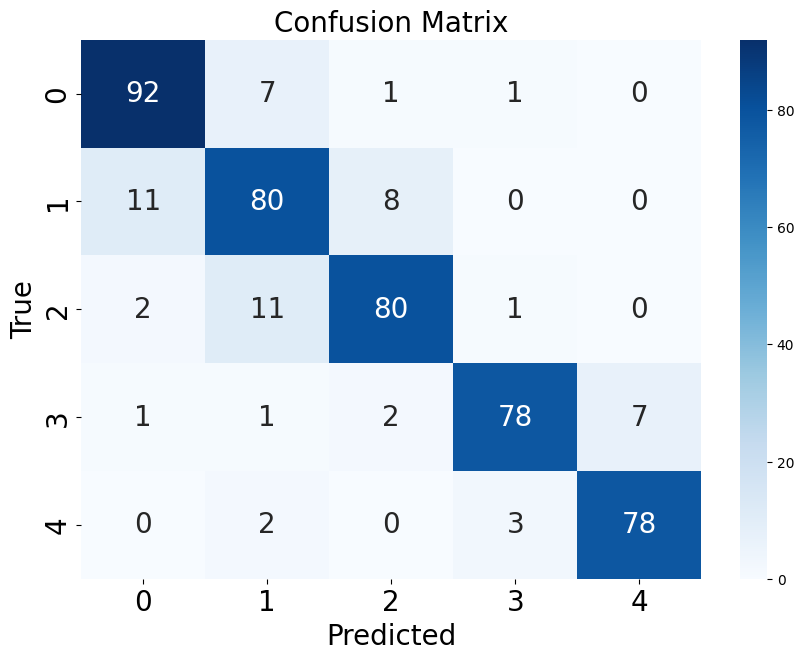

In [15]:
# Plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1', '2', '3', '4'], yticklabels=['0', '1', '2', '3', '4'], annot_kws={"size": 20})
plt.xlabel('Predicted', fontsize=20)
plt.ylabel('True', fontsize=20)
plt.title('Confusion Matrix', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()